In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [17]:
df = pd.read_csv("D:\\gow\\archive\\creditcard.csv")

In [29]:
x = df.drop(columns=["Class"]).values
y = df["Class"].values
print("Shape x:", x.shape,"| Shape y:",y.shape)
print("Fraud count:", int(y.sum()), " Fraud %:",100*y.mean())

Shape x: (284807, 30) | Shape y: (284807,)
Fraud count: 492  Fraud %: 0.1727485630620034


In [31]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

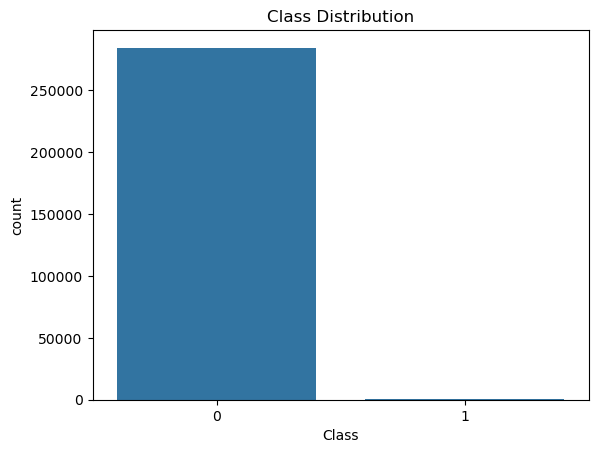

In [37]:
import seaborn as sns

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

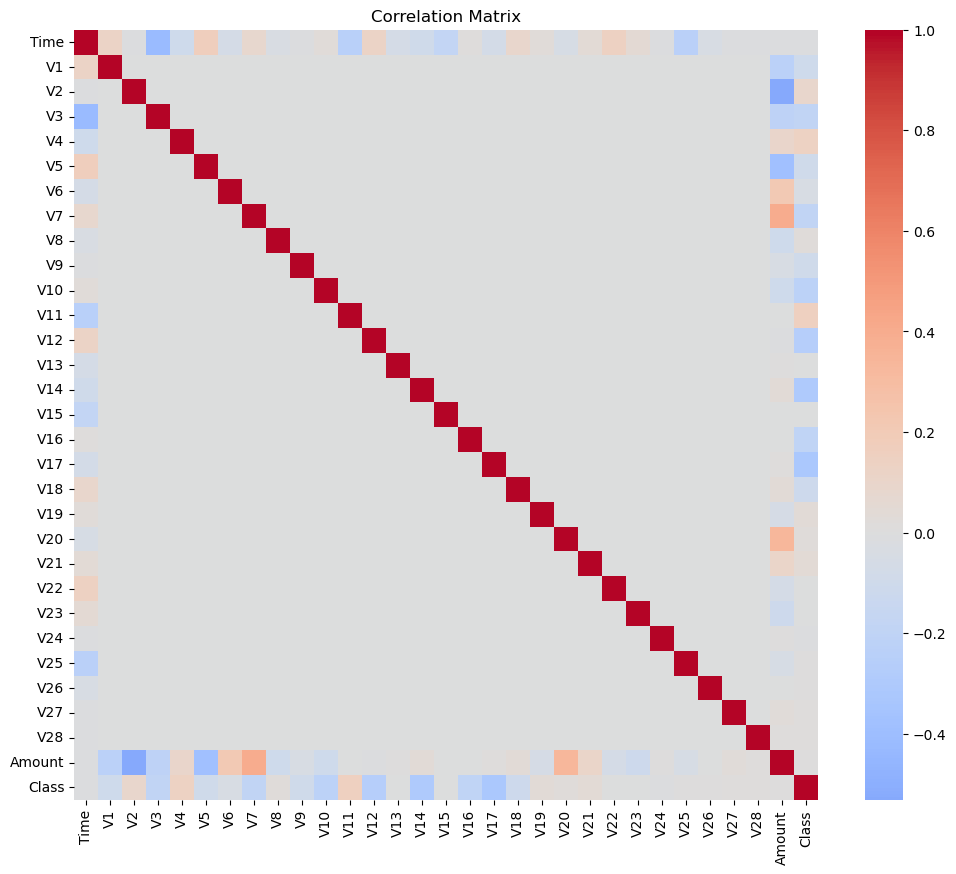

In [39]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [43]:
fraud = df[df["Class"]==1]
fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


In [45]:
x_trainable,x_test,y_trainable,y_test = train_test_split(
    x,y,test_size=0.20, random_state=42)
x_train,x_val,y_train,y_val = train_test_split(
    x_trainable,y_trainable,test_size=0.20,random_state=42)

In [47]:
mu = x_train.mean(axis=0)
sigma = x_train.std(axis=0)

eps = 1e-15
x_train_s = (x_train -mu) / (sigma+eps)
x_val_s = (x_val - mu) / (sigma+eps)
x_test_s = (x_test - mu) / (sigma+eps)

print("Standardized shapes:", x_train_s.shape, x_val_s.shape, x_test_s.shape)

Standardized shapes: (182276, 30) (45569, 30) (56962, 30)


In [49]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logloss(y,p):
    p = np.clip(p, eps,1 - eps)
    losses = -(y*np.log(p) + (1-y)*np.log(1-p))

    return np.mean(losses)

def compute_class_weights(y):
    n = len(y)
    n1 = np.sum(y == 1)
    n0 = n - n1
    w1 = n / (2 * max(1.0, n1))
    w0 = n / (2 * max(1.0, n0))
    return float(w0), float(w1)

In [63]:
def train_logreg_with_val(x_train, y_train, x_val, y_val, lr=0.01, epochs=200, weighted_loss=False):
    n, d = x_train.shape
    w = np.zeros(d)
    b = 0.0

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        # ---- forward pass -----
        z = x_train @ w + b
        p = sigmoid(z)

        # ----- gradients (traditional) -----
        error = (p - y_train)

        if weighted_loss:
            w0, w1 = compute_class_weights(y_train)
        else:
            w0, w1 = 1.0, 1.0

        ws = np.where(y_train==1, w1, w0)
        weighted_error = ws * error
        dw = (x_train.T @ weighted_error) / n
        db = np.mean(weighted_error)

        # ------ update --------
        w -= lr * dw
        b -= lr * db

        # ------ train/val loss -------
        train_loss = logloss(y_train,p)

        z_val = x_val @ w + b
        p_val = sigmoid(z_val)
        val_loss = logloss(y_val,p_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ------- print progress --------
        if (epoch%5 == 0):
            print(f"epoch:{epoch:4d} train_logloss={train_loss:.6f} val_logloss={val_loss:.6f}")

    return w, b, train_losses, val_losses

In [65]:
w, b, train_losses, val_losses = train_logreg_with_val(
    x_train_s, y_train, x_val_s, y_val,
    lr=0.05, epochs=1000, weighted_loss=True)

epoch:   5 train_logloss=0.675442 val_logloss=0.670817
epoch:  10 train_logloss=0.653079 val_logloss=0.648631
epoch:  15 train_logloss=0.631676 val_logloss=0.627418
epoch:  20 train_logloss=0.611284 val_logloss=0.607214
epoch:  25 train_logloss=0.591903 val_logloss=0.588017
epoch:  30 train_logloss=0.573509 val_logloss=0.569798
epoch:  35 train_logloss=0.556065 val_logloss=0.552520
epoch:  40 train_logloss=0.539529 val_logloss=0.536140
epoch:  45 train_logloss=0.523855 val_logloss=0.520613
epoch:  50 train_logloss=0.508997 val_logloss=0.505892
epoch:  55 train_logloss=0.494910 val_logloss=0.491933
epoch:  60 train_logloss=0.481548 val_logloss=0.478691
epoch:  65 train_logloss=0.468870 val_logloss=0.466124
epoch:  70 train_logloss=0.456835 val_logloss=0.454193
epoch:  75 train_logloss=0.445404 val_logloss=0.442859
epoch:  80 train_logloss=0.434541 val_logloss=0.432086
epoch:  85 train_logloss=0.424211 val_logloss=0.421841
epoch:  90 train_logloss=0.414384 val_logloss=0.412091
epoch:  95

In [69]:
def predict_proba(x, w, b):
    return sigmoid(x @ w + b)

p_test = predict_proba(x_test_s, w, b)
y_pred = (p_test >=0.99).astype(int)

TP = int(np.sum((y_test == 1) & (y_pred == 1)))
TN = int(np.sum((y_test == 0) & (y_pred == 0)))
FP = int(np.sum((y_test == 0) & (y_pred == 1)))
FN = int(np.sum((y_test == 1) & (y_pred == 0)))

prec = TP / max(1, (TP + FP))
rec = TP / max(1, (TP + FN))
f1 = 2 * prec * rec / max(1e-12, (prec + rec))

print("Confusion Matrix:")
print("TP:", TP, " FP:", FP, " FN:", FN, " TN:", TN)
print("Recall  :",rec)
print("F1   :",f1)

Confusion Matrix:
TP: 78  FP: 22  FN: 20  TN: 56842
Recall  : 0.7959183673469388
F1   : 0.7878787878787878


ROC-AUC: 0.9792491022908013


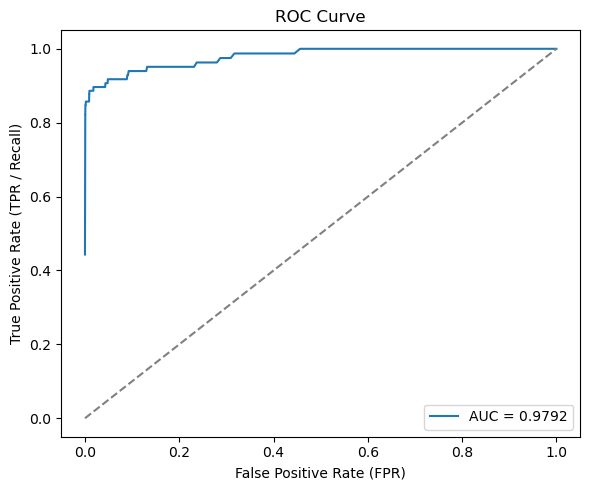

In [77]:
#-------------------
# ROC Curve + AUC
#--------------------

def compute_roc_curve(y_true, y_score, num_thresholds=500):
    """
    y_true : true labels (0/1)
    y_score : predicted probabilities
    """
    thresholds = np.linspace(1.0, 0.0, num_thresholds)

    tpr_list = []
    fpr_list = []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        
        TN = int(np.sum((y_true == 0) & (y_pred == 0)))
        FP = int(np.sum((y_true == 0) & (y_pred == 1)))
        FN = int(np.sum((y_true == 1) & (y_pred == 0)))

        TPR = TP / max(1, (TP + FN))
        FPR = FP / max(1, (FP + TN))

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    return np.array(fpr_list), np.array(tpr_list)


def compute_auc(fpr, tpr):
    """

    Trapezoidal rule
    """

    # sort by FPR ascending
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]

    return np.trapz(tpr, fpr)


#-------------------------
# Compute ROC and AUC
#-------------------------

fpr, tpr = compute_roc_curve(y_test, p_test)
roc_auc = compute_auc(fpr, tpr)

print("ROC-AUC:", roc_auc)

#-------------------
#Plot
#-------------------

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()